In [2]:
!pip install lifelines

  Using cached lifelines-0.30.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached autograd-1.8.0-py3-none-any.whl.metadata (7.5 kB)
  Using cached autograd_gamma-0.5.0-py3-none-any.whl
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
Using cached lifelines-0.30.3-py3-none-any.whl (409 kB)
Using cached autograd-1.8.0-py3-none-any.whl (51 kB)
Using cached interface_meta-2.0.1-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [lifelines]/5 [lifelines]


In [3]:
!pip install jinja2

In [4]:
!pip install openpyxl

In [5]:
!pip install seaborn

In [6]:
import pandas as pd
from lifelines import LogNormalAFTFitter, LogLogisticAFTFitter, WeibullAFTFitter
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter

In [7]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

In [8]:
X = df.iloc[:, :-1]  #wszystkie kolumny oprócz ostatniej
y = df.iloc[:, -1]   #ostatnia kolumna jako target

In [9]:
print(df.columns)

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')


In [10]:
#lista zmiennych objaśniajcych
variables = ['age', 'anaemia', 'ejection_fraction', 'high_blood_pressure', 'serum_creatinine', 'serum_sodium']

In [11]:
data = df[variables + ['time', 'DEATH_EVENT']]

In [12]:
#modele do porównania
models = {
    "Weibull AFT": WeibullAFTFitter(),
    "Log-Logistic AFT": LogLogisticAFTFitter(),
    "Log-Normal AFT": LogNormalAFTFitter()
}

In [13]:
#lista na wyniki
results = []

for name, model in models.items():
    model.fit(data, duration_col='time', event_col='DEATH_EVENT')
    results.append({
        'Model': name,
        'AIC': model.AIC_,
        'Concordance': model.concordance_index_
    })

In [14]:
#podsumowanie wyników
results_df = pd.DataFrame(results).sort_values(by='AIC')
print(results_df)

              Model          AIC  Concordance
0       Weibull AFT  1277.623731     0.729185
1  Log-Logistic AFT  1280.359045     0.729761
2    Log-Normal AFT  1282.557043     0.731393


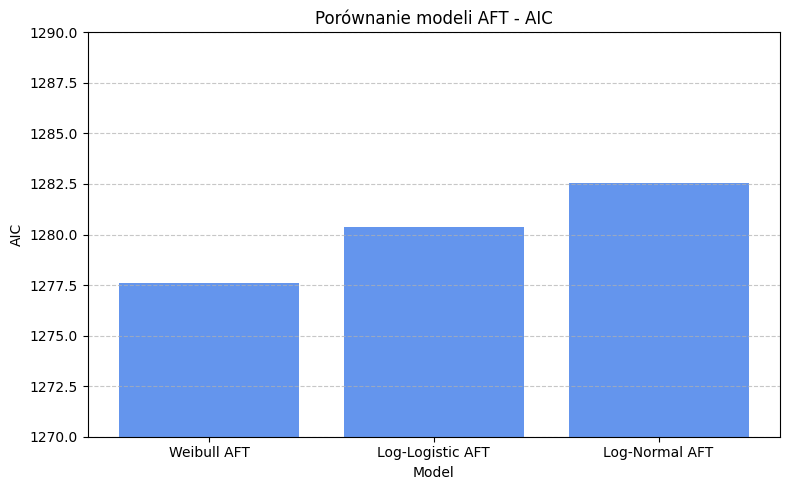

In [15]:
#wykres AIC
plt.figure(figsize=(8, 5))
plt.bar(results_df['Model'], results_df['AIC'], color='cornflowerblue')
plt.title('Porównanie modeli AFT - AIC')
plt.ylabel('AIC')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.ylim(1270, 1290)  

plt.tight_layout()
plt.show()

In [16]:
#zmienne kategoryczne i liczbowe
categorical_vars = ['anaemia', 'high_blood_pressure']
numeric_vars = ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium']

In [17]:
#kolumny czasu i zdarzenia
outcome_vars = ['time', 'DEATH_EVENT']

In [18]:
#model bez zmiennych nieistotnych
model_data = df[categorical_vars + numeric_vars + outcome_vars]

In [19]:
print("Liczba kolumn w modelu:", len(model_data.columns))
model_data.head()

Liczba kolumn w modelu: 8


,anaemia,high_blood_pressure,age,ejection_fraction,serum_creatinine,serum_sodium,time,DEATH_EVENT
0,0,1,75.0,20,1.9,130,4,1
1,0,0,55.0,38,1.1,136,6,1
2,0,0,65.0,20,1.3,129,7,1
3,1,0,50.0,20,1.9,137,7,1
4,1,0,65.0,20,2.7,116,8,1


In [20]:
#dopasowanie modelu Weibulla
aft = WeibullAFTFitter()
aft.fit(model_data, duration_col='time', event_col='DEATH_EVENT')

<lifelines.WeibullAFTFitter: fitted with 299 total observations, 203 right-censored observations>

In [21]:
#wyświetlenie wyników dopasowania modelu Weibulla
aft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
   number of observations = 299
number of events observed = 96
           log-likelihood = -630.81
         time fit was run = 2026-06-11 16:56:34 UTC

---
                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                            
lambda_ age                 -0.05      0.95      0.01           -0.07           -0.03                0.94                0.97
        anaemia             -0.42      0.66      0.22           -0.85            0.01                0.43                1.01
        ejection_fraction    0.05      1.05      0.01            0.03            0.07                1.03                1.08
        high_blood_pressure -0.51      0.60      0.22           -0.95           -0.08                0.39                0.92
        serum_creatinine    -0.32      0.73      0.07           -0.46           -0.17                0.63                0.84
        serum_sodium         0.04      1.05      0.02           -0.00            0.09                1.00                1.10
        Intercept            1.95      7.01      3.33           -4.58            8.48                0.01             4806.11
rho_    Intercept           -0.05      0.96      0.09           -0.22            0.13                0.80                1.14

                             cmp to     z      p  -log2(p)
param   covariate                                         
lambda_ age                    0.00 -4.88 <0.005     19.87
        anaemia                0.00 -1.93   0.05      4.22
        ejection_fraction      0.00  4.46 <0.005     16.87
        high_blood_pressure    0.00 -2.32   0.02      5.63
        serum_creatinine       0.00 -4.34 <0.005     16.12
        serum_sodium           0.00  1.80   0.07      3.80
        Intercept              0.00  0.58   0.56      0.84
rho_    Intercept              0.00 -0.52   0.61      0.72
---
Concordance = 0.73
AIC = 1277.62
log-likelihood ratio test = 79.25 on 6 df
-log2(p) of ll-ratio test = 47.48

In [22]:
#uzyskanie podsumowania w formie DataFrame
summary_df = aft.summary

In [23]:
#zapisanie do pliku Excel
summary_df.to_excel('aft_summary_results.xlsx', index=True)
print("Wyniki zostały zapisane do pliku 'aft_summary_results.xlsx'")

Wyniki zostały zapisane do pliku 'aft_summary_results.xlsx'


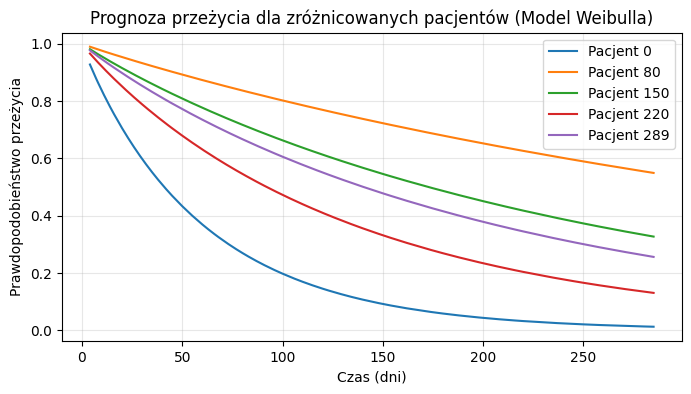

In [24]:
#wybranie pacjentów z różnych części bazy
zroznicowani_pacjenci = model_data.iloc[[0, 80, 150, 220, 289]]

#funkcje przeżycia dla zróżnicowanych pacjentów
surv_funcs_diverse = aft.predict_survival_function(zroznicowani_pacjenci)

plt.figure(figsize=(8, 4))
surv_funcs_diverse.plot(ax=plt.gca())

plt.title("Prognoza przeżycia dla zróżnicowanych pacjentów (Model Weibulla)")
plt.xlabel("Czas (dni)")
plt.ylabel("Prawdopodobieństwo przeżycia")
plt.legend([f"Pacjent {i}" for i in zroznicowani_pacjenci.index])
plt.grid(True, alpha=0.3)
plt.show()

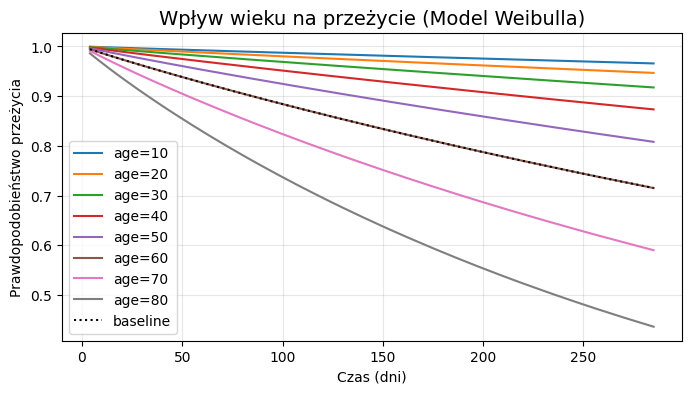

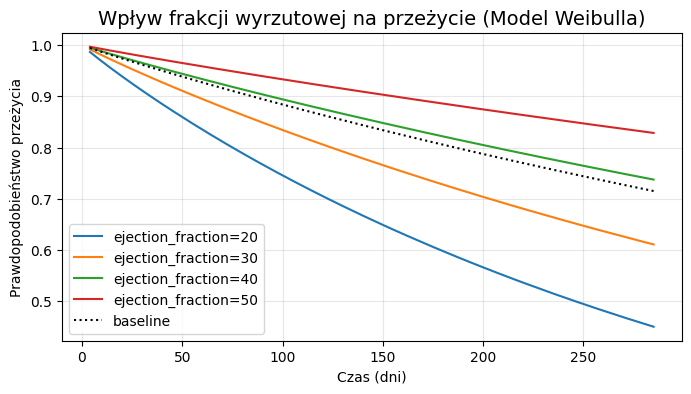

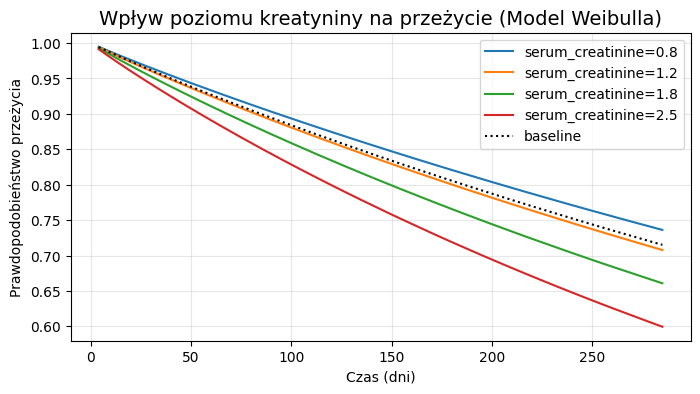

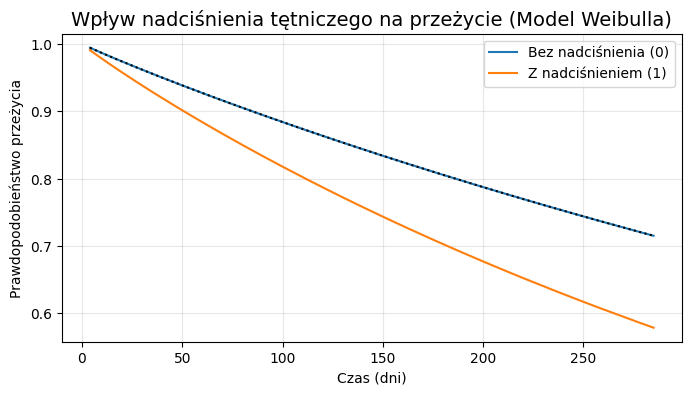

In [25]:
#zmienne o bardzo silnych wpływie statystycznym - p < 0,005
#wpływ wieku (najsilniejsza zmienne)
plt.figure(figsize=(8, 4))
aft.plot_partial_effects_on_outcome(covariates='age', values=[10, 20, 30, 40, 50, 60, 70, 80])
plt.title("Wpływ wieku na przeżycie (Model Weibulla)", fontsize=14)
plt.xlabel("Czas (dni)")
plt.ylabel("Prawdopodobieństwo przeżycia")
plt.grid(True, alpha=0.3)
plt.show()

#wpływ frakcji wyrzutowej (kluczowy wskaźnik kardiologcnzy)
plt.figure(figsize=(8, 4))
aft.plot_partial_effects_on_outcome(covariates='ejection_fraction', values=[20, 30, 40, 50])
plt.title("Wpływ frakcji wyrzutowej na przeżycie (Model Weibulla)", fontsize=14)
plt.xlabel("Czas (dni)")
plt.ylabel("Prawdopodobieństwo przeżycia")
plt.grid(True, alpha=0.3)
plt.show()

#wpływ kreateniny w surowicy
plt.figure(figsize=(8, 4))
aft.plot_partial_effects_on_outcome(covariates='serum_creatinine', values=[0.8, 1.2, 1.8, 2.5])
plt.title("Wpływ poziomu kreatyniny na przeżycie (Model Weibulla)", fontsize=14)
plt.xlabel("Czas (dni)")
plt.ylabel("Prawdopodobieństwo przeżycia")
plt.grid(True, alpha=0.3)
plt.show()

#zmienna o istotnym wpływie statystycznym (p = 0,02 < 0,05)
#wpływ nadciśnienia tętniczego (zmienna kategoryczna 0/1)
plt.figure(figsize=(8, 4))
aft.plot_partial_effects_on_outcome(covariates='high_blood_pressure', values=[0, 1])
plt.title("Wpływ nadciśnienia tętniczego na przeżycie (Model Weibulla)", fontsize=14)
plt.xlabel("Czas (dni)")
plt.ylabel("Prawdopodobieństwo przeżycia")
plt.legend(["Bez nadciśnienia (0)", "Z nadciśnieniem (1)"])
plt.grid(True, alpha=0.3)
plt.show()

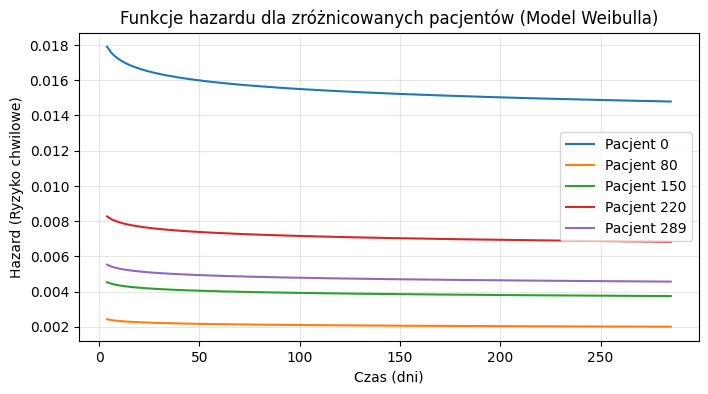

In [26]:
#funkcja hazardu dla wybranych pacjentów
hazard_funcs_diverse = aft.predict_hazard(zroznicowani_pacjenci)
plt.figure(figsize=(8, 4))
hazard_funcs_diverse.plot(ax=plt.gca())
plt.title("Funkcje hazardu dla zróżnicowanych pacjentów (Model Weibulla)")
plt.xlabel("Czas (dni)")
plt.ylabel("Hazard (Ryzyko chwilowe)")
plt.legend([f"Pacjent {i}" for i in zroznicowani_pacjenci.index])
plt.grid(True, alpha=0.3)
plt.show()

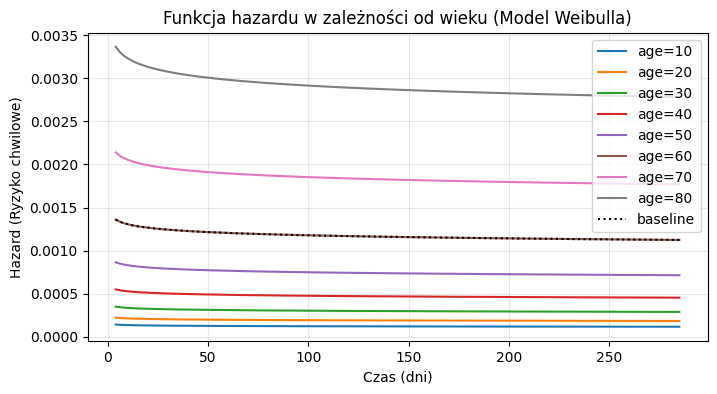

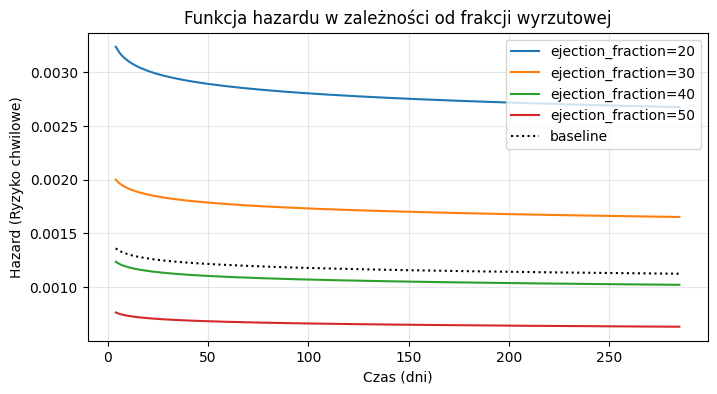

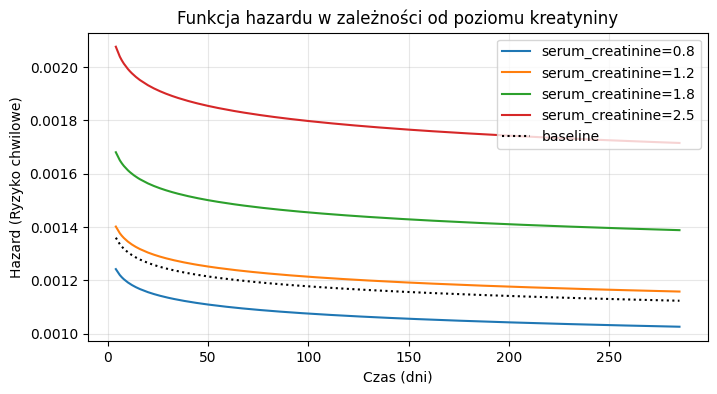

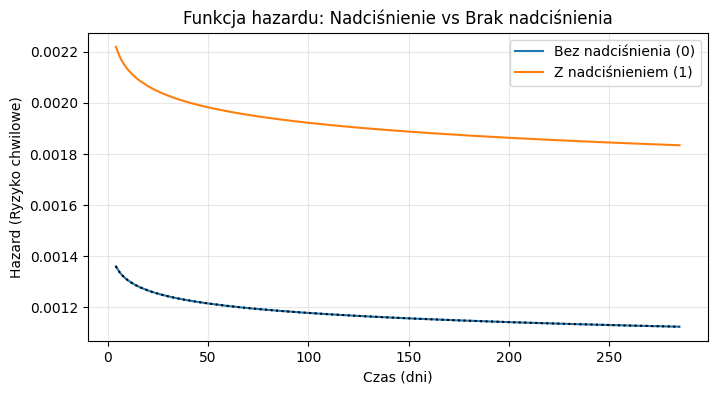

In [27]:
#zmienne o bardzo silnych wpływie statystycznym - p < 0,005
#wpływ wieku na hazard
plt.figure(figsize=(8, 4))
aft.plot_partial_effects_on_outcome(covariates='age', values=[10, 20, 30, 40, 50, 60, 70, 80], y='hazard')
plt.title("Funkcja hazardu w zależności od wieku (Model Weibulla)", fontsize=12)
plt.xlabel("Czas (dni)")
plt.ylabel("Hazard (Ryzyko chwilowe)")
plt.grid(True, alpha=0.3)
plt.show()

#wpływ frakcji wyrzutowej na hazard
plt.figure(figsize=(8, 4))
aft.plot_partial_effects_on_outcome(covariates='ejection_fraction', values=[20, 30, 40, 50], y='hazard')
plt.title("Funkcja hazardu w zależności od frakcji wyrzutowej", fontsize=12)
plt.xlabel("Czas (dni)")
plt.ylabel("Hazard (Ryzyko chwilowe)")
plt.grid(True, alpha=0.3)
plt.show()

#wpływ kreateniny w surowicy na hazard
plt.figure(figsize=(8, 4))
aft.plot_partial_effects_on_outcome(covariates='serum_creatinine', values=[0.8, 1.2, 1.8, 2.5], y='hazard')
plt.title("Funkcja hazardu w zależności od poziomu kreatyniny", fontsize=12)
plt.xlabel("Czas (dni)")
plt.ylabel("Hazard (Ryzyko chwilowe)")
plt.grid(True, alpha=0.3)
plt.show()

#zmienna o istotnym wpływie statystycznym (p = 0,02 < 0,05)
#wpływ nadciśnienia tętniczego na hazard
plt.figure(figsize=(8, 4))
aft.plot_partial_effects_on_outcome(covariates='high_blood_pressure', values=[0, 1], y='hazard')
plt.title("Funkcja hazardu: Nadciśnienie vs Brak nadciśnienia", fontsize=12)
plt.xlabel("Czas (dni)")
plt.ylabel("Hazard (Ryzyko chwilowe)")
plt.legend(["Bez nadciśnienia (0)", "Z nadciśnieniem (1)"])
plt.grid(True, alpha=0.3)
plt.show()

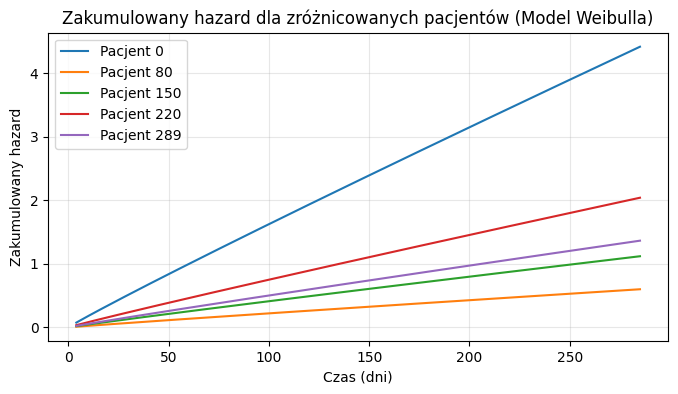

In [28]:
#zakumulowany hazard (cumulative hazard)
cum_hazard_diverse = aft.predict_cumulative_hazard(zroznicowani_pacjenci)

plt.figure(figsize=(8, 4))
cum_hazard_diverse.plot(ax=plt.gca())

plt.title("Zakumulowany hazard dla zróżnicowanych pacjentów (Model Weibulla)")
plt.xlabel("Czas (dni)")
plt.ylabel("Zakumulowany hazard")
plt.legend([f"Pacjent {i}" for i in zroznicowani_pacjenci.index])
plt.grid(True, alpha=0.3)
plt.show()

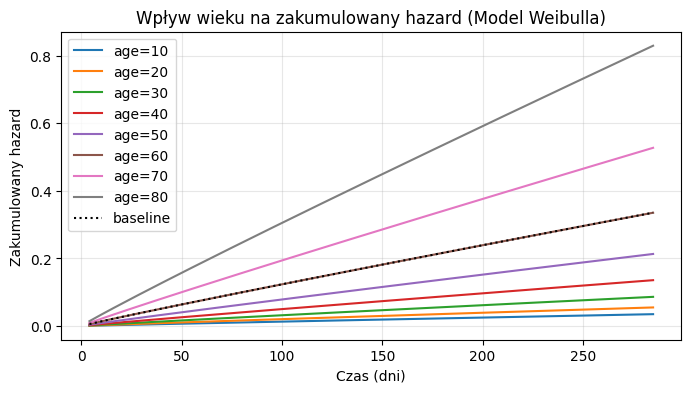

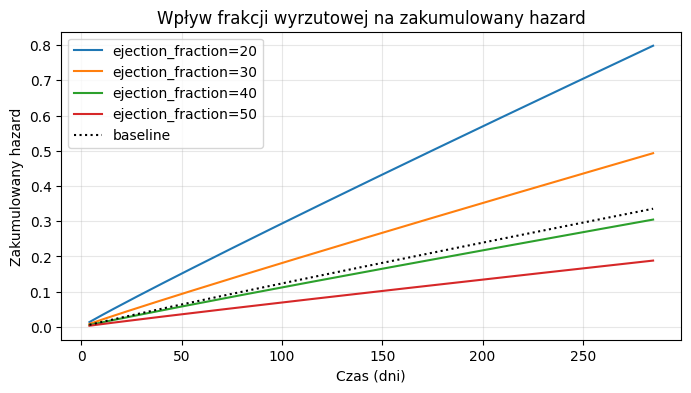

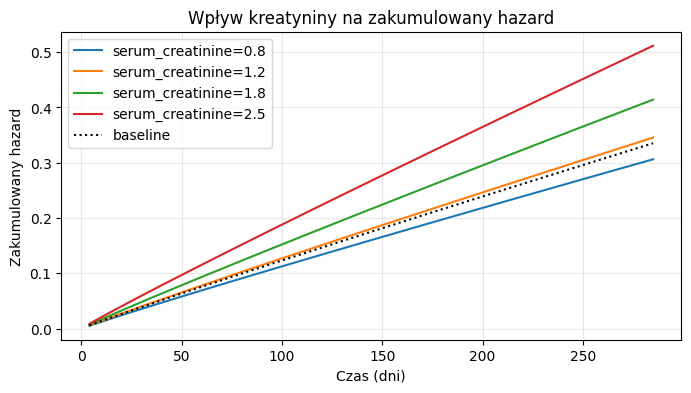

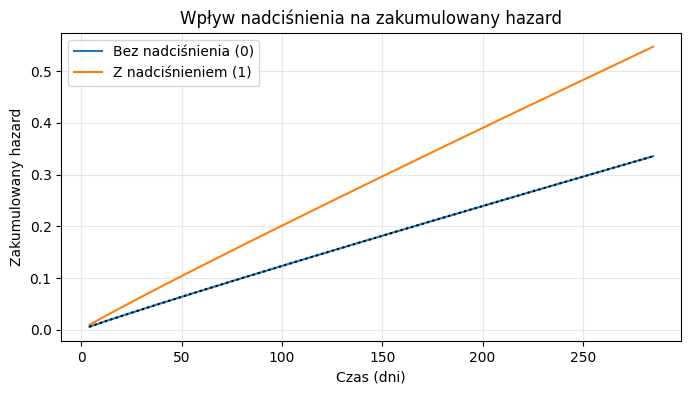

In [29]:
#zmienne o bardzo silnych wpływie statystycznym - p < 0,005
#wpływ wieku na hazard
plt.figure(figsize=(8, 4))
aft.plot_partial_effects_on_outcome(covariates='age', values=[10, 20, 30, 40, 50, 60, 70, 80], y='cumulative_hazard')
plt.title("Wpływ wieku na zakumulowany hazard (Model Weibulla)", fontsize=12)
plt.xlabel("Czas (dni)")
plt.ylabel("Zakumulowany hazard")
plt.grid(True, alpha=0.3)
plt.show()

#wpływ frakcji wyrzutowej na hazard
plt.figure(figsize=(8, 4))
aft.plot_partial_effects_on_outcome(covariates='ejection_fraction', values=[20, 30, 40, 50], y='cumulative_hazard')
plt.title("Wpływ frakcji wyrzutowej na zakumulowany hazard", fontsize=12)
plt.xlabel("Czas (dni)")
plt.ylabel("Zakumulowany hazard")
plt.grid(True, alpha=0.3)
plt.show()

#wpływ kreateniny w surowicy na hazard
plt.figure(figsize=(8, 4))
aft.plot_partial_effects_on_outcome(covariates='serum_creatinine', values=[0.8, 1.2, 1.8, 2.5], y='cumulative_hazard')
plt.title("Wpływ kreatyniny na zakumulowany hazard", fontsize=12)
plt.xlabel("Czas (dni)")
plt.ylabel("Zakumulowany hazard")
plt.grid(True, alpha=0.3)
plt.show()

#zmienna o istotnym wpływie statystycznym (p = 0,02 < 0,05)
#wpływ nadciśnienia tętniczego na hazard
plt.figure(figsize=(8, 4))
aft.plot_partial_effects_on_outcome(covariates='high_blood_pressure', values=[0, 1], y='cumulative_hazard')
plt.title("Wpływ nadciśnienia na zakumulowany hazard", fontsize=12)
plt.xlabel("Czas (dni)")
plt.ylabel("Zakumulowany hazard")
plt.legend(["Bez nadciśnienia (0)", "Z nadciśnieniem (1)"])
plt.grid(True, alpha=0.3)
plt.show()

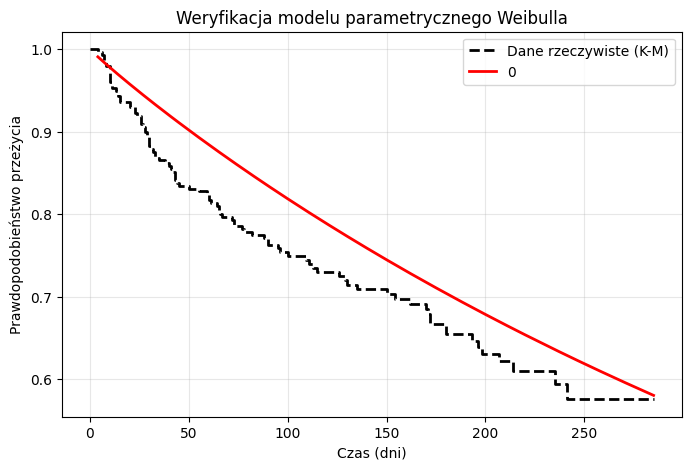

In [30]:
#porównanie funkcji przeżycia modelu Weibulla z estymatorem Kaplana-Meiera
#dane K-M (rzeczywiste)
kmf = KaplanMeierFitter()
kmf.fit(model_data['time'], event_observed=model_data['DEATH_EVENT'], label='Dane rzeczywiste (K-M)')
plt.figure(figsize=(8, 5))
ax = kmf.plot_survival_function(ci_show=False, color='black', linestyle='--', linewidth=2)

#przewidywanie modelu Weibulla
aft.predict_survival_function(model_data.mean()).plot(ax=ax, color='red', linewidth=2, label='Model Weibulla (Przewidywany)')

plt.title("Weryfikacja modelu parametrycznego Weibulla")
plt.xlabel("Czas (dni)")
plt.ylabel("Prawdopodobieństwo przeżycia")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
#macierz kowariancji (z wariancjami i kowariancjami dla parametrów lambda_ i rho_)
cov_matrix = aft.variance_matrix_

#konwersja macierzy kowariancji na DataFrame
cov_matrix_df = pd.DataFrame(cov_matrix, index=aft.params_.index, columns=aft.params_.index)

#zapisanie macierzy kowariancji do pliku Excel
cov_matrix_df.to_excel('macierz_kowariancji_projekt.xlsx', index=True)
print("Macierz kowariancji została zapisana do pliku 'macierz_kowariancji_projekt.xlsx'")

Macierz kowariancji została zapisana do pliku 'macierz_kowariancji_projekt.xlsx'


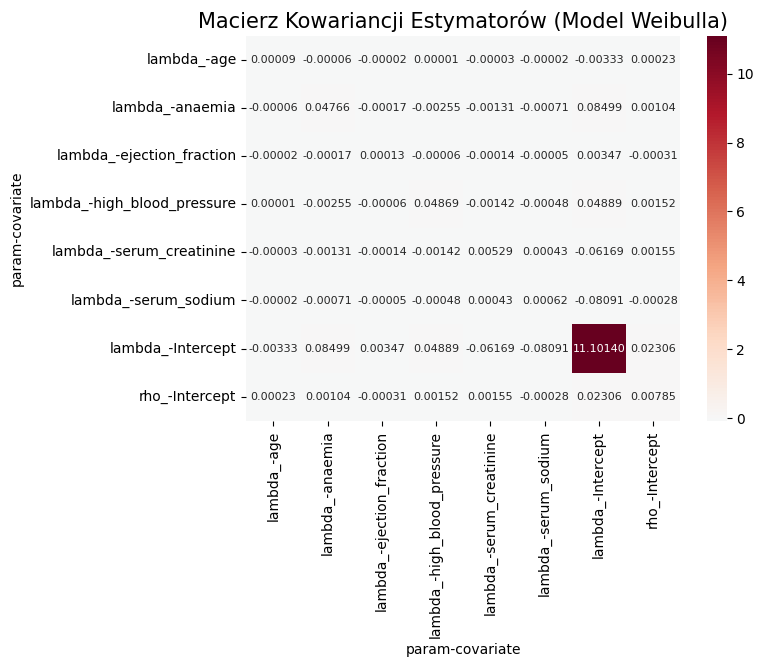

In [32]:
#wyświetlenie macierzy w formie Heatmapy
plt.figure(figsize=(7, 5))
sns.heatmap(cov_matrix_df, annot=True, fmt=".5f", cmap='RdBu_r', center=0, annot_kws={"size": 8})
plt.title("Macierz Kowariancji Estymatorów (Model Weibulla)", fontsize=15)
plt.show()

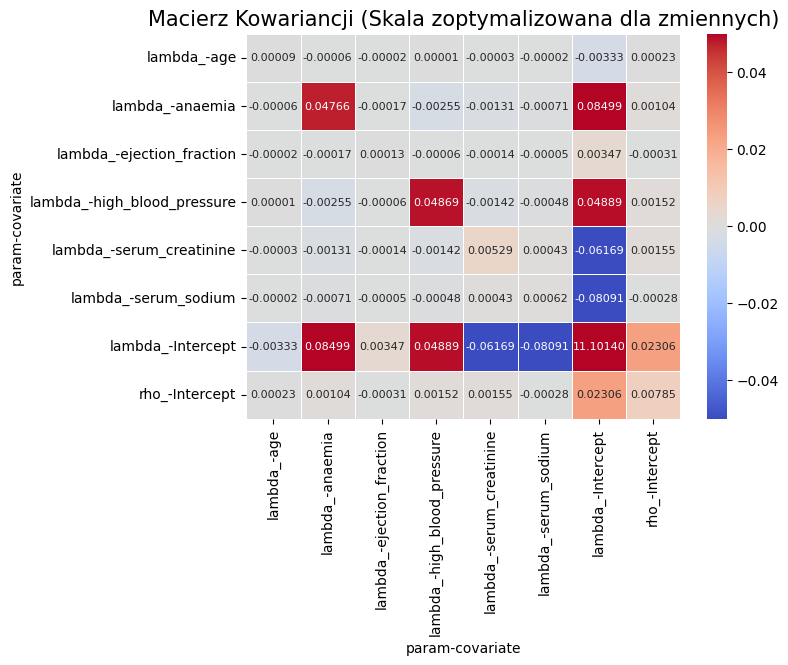

In [33]:
#wyświetlenie macierzy w formie Heatmapy o ograniczonej skali
plt.figure(figsize=(7, 5))
sns.heatmap(cov_matrix_df, annot=True, fmt=".5f", cmap='coolwarm', center=0, annot_kws={"size": 8}, vmin=-0.05, vmax=0.05, linewidths=.5)
plt.title("Macierz Kowariancji (Skala zoptymalizowana dla zmiennych)", fontsize=15)
plt.show()

In [34]:
#macierz kowariancji współczynników (jak COVB w SAS)
print("\nMacierz kowariancji (COVB) dla modelu Weibulla:")
print(aft.variance_matrix_)


Macierz kowariancji (COVB) dla modelu Weibulla:
param                         lambda_                              \
covariate                         age   anaemia ejection_fraction   
param   covariate                                                   
lambda_ age                  0.000094 -0.000059         -0.000015   
        anaemia             -0.000059  0.047656         -0.000171   
        ejection_fraction   -0.000015 -0.000171          0.000128   
        high_blood_pressure  0.000012 -0.002552         -0.000060   
        serum_creatinine    -0.000027 -0.001312         -0.000136   
        serum_sodium        -0.000018 -0.000706         -0.000046   
        Intercept           -0.003328  0.084986          0.003472   
rho_    Intercept            0.000232  0.001037         -0.000314   

param                                                                          \
covariate                   high_blood_pressure serum_creatinine serum_sodium   
param   covariate            

In [35]:
#cenzurowanie lewo i prawostronne
#W badanym zbiorze danych dotyczacym niewydolności serca występuje prawostronne cenzurowanie (rght censoring). 
#Dotyczy ono pacjentów, którzy zostali oznaczeni wartościa 0 w kolumnie DEATH_EVENT. 
#Dla tych osób zdarzenie końcowe nie wystapiło do momentu zakończenia obserwacji, co oznacza, że ich rzeczywisty czas przeżycia
#jest dłuższy niż wartość odnotowana w kolumnie time.
#Lewostronne cenzuorowanie (left censoring) nie występuje w tym badaniu. Każdy pacjent trafia do bazy w konkretnym momencie
#i od tego czasu jest montorowany. Nie ma sytuacji, w której wiemy, że zdarzenie wystapiło przed określonym czasem,
#ale nie wiemy kiedy - moment startowy jest precyzyjnie określony dla każdego rekordu.
#do analizy wystarczy uwzględnić prawostronne cenzurowanie, ktøre jest domyślnie obsługiwane przez modele przeżycia 
#po przekazaniu kolumn time oraz DEATH_EVENT

In [36]:
#Cenzurowanie interwałowe (interval censoring) nie jest konieczne do uwzględnienia w tym modelu. 
#Chociaż pacjenci z niewydolnościa serca moga pojawiać się na wizytach kontrolnych w pewnych odstępach czasu,
#to zdarzenie końcowe (zgon) jest odnotowane z precyzja do jednego dnia. 
#Ponieważ znamy dokładny dzień wystapienia zdarzenia (lub dzień ostatniego kontaltu w przypadku cenzurowania prawostronnego),
#traktujemy czas jako zmienn ciagła, a nie przedziałowa.

In [ ]:
#predykcja mediany czasu przeżycia z głównego modelu
mediany = aft.predict_median(model_data)

#bootstrap
n_iterations = 100
all_medians = []

for i in range(n_iterations):
    #losowanie z powtórzeniami i resetowanie indeksu
    sample = model_data.sample(frac=1, replace=True).reset_index(drop=True)
    
    #dopasowanie modelu do wylosowanej próby
    aft_bs = WeibullAFTFitter()
    try:
        aft_bs.fit(sample, duration_col='time', event_col='DEATH_EVENT')
        #predykcja na oryginalnym zbiorze danych (żeby porównywać te same punkty)
        pred = aft_bs.predict_median(model_data)
        all_medians.append(pred)
    except:
        #pomija jeśli model nie zbiegnie się w danej iteracji
        continue

#lączenie wyników i obliczanie błędów
bootstrap_df = pd.concat(all_medians, axis=1)
stds = bootstrap_df.std(axis=1)

#tworzenie końcowego zestawienia
wyniki = pd.DataFrame({
    "Mediana": mediany,
    "Odchylenie standardowe (Bootstrap)": stds
})

print("Gotowe!")
print(wyniki)

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(wyniki['Mediana'], wyniki['Odchylenie standardowe (Bootstrap)'], alpha=0.5)
plt.title("Zależność błędu od przewidywanego czasu przeżycia")
plt.xlabel("Przewidywana Mediana (dni)")
plt.ylabel("Błąd standardowy (Bootstrap)")
plt.grid(True, alpha=0.3)
plt.show()